In [34]:
import os
from pathlib import Path
from langgraph.prebuilt import create_react_agent
from langchain_core.tools import Tool
from langchain_community.tools import WikipediaQueryRun
from langchain_community.utilities import WikipediaAPIWrapper
from langchain_community.vectorstores import FAISS
from langchain_community.document_loaders import WebBaseLoader
from langchain.text_splitter import RecursiveCharacterTextSplitter
from langgraph.graph import END
from langgraph.graph import StateGraph
from typing import Annotated, TypedDict, Sequence
from langchain_core.messages import BaseMessage, HumanMessage, AIMessage
from langgraph.graph.message import add_messages
from langchain_huggingface import HuggingFaceEmbeddings
from langchain_core.documents import Document


In [35]:
# --------------------------
# 1. Create Retriever Tool
# --------------------------

# Load content from blog
docs = WebBaseLoader("https://lilianweng.github.io/posts/2023-06-23-agent/").load()
splitter = RecursiveCharacterTextSplitter(chunk_size=500, chunk_overlap=50)
chunks = splitter.split_documents(docs)

embedding = HuggingFaceEmbeddings()
vectorstore = FAISS.from_documents(chunks, embedding)
retriever = vectorstore.as_retriever()

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

In [11]:
def retriever_tool_func(query: str) -> str:
    print("📚 Using RAGRetriever tool")
    docs = retriever.invoke(query)
    return "\n".join([doc.page_content for doc in docs])

In [12]:
retriever_tool_func("what are autonomous agents")

📚 Using RAGRetriever tool


"Citation#\nCited as:\n\nWeng, Lilian. (Jun 2023). “LLM-powered Autonomous Agents”. Lil’Log. https://lilianweng.github.io/posts/2023-06-23-agent/.\nLLM Powered Autonomous Agents | Lil'Log\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\nLil'Log\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n|\n\n\n\n\n\n\nPosts\n\n\n\n\nArchive\n\n\n\n\nSearch\n\n\n\n\nTags\n\n\n\n\nFAQ\n\n\n\n\n\n\n\n\n\n      LLM Powered Autonomous Agents\n    \nDate: June 23, 2023  |  Estimated Reading Time: 31 min  |  Author: Lilian Weng\n\n\n \n\n\nTable of Contents\n\n\n\nAgent System Overview\n\nComponent One: Planning\n\nTask Decomposition\n\nSelf-Reflection\n\n\nComponent Two: Memory\n\nTypes of Memory\n\nMaximum Inner Product Search (MIPS)\nTool use\n\nThe agent learns to call external APIs for extra information that is missing from the model weights (often hard to change after pre-training), including current information, code execution capability, access to proprietary information sources an

In [13]:
retriever_tool=Tool(
    name="RAGRetriever",
    description="Use this tool to fetch relevant knowledge base info",
    func=retriever_tool_func
)
retriever_tool
print(retriever_tool.name)

RAGRetriever


In [14]:
wiki_tool = WikipediaQueryRun(api_wrapper=WikipediaAPIWrapper())
wiki_tool

WikipediaQueryRun(api_wrapper=WikipediaAPIWrapper(wiki_client=<module 'wikipedia' from 'c:\\Users\\DELL\\anaconda3\\Lib\\site-packages\\wikipedia\\__init__.py'>, top_k_results=3, lang='en', load_all_available_meta=False, doc_content_chars_max=4000))

In [15]:
from dotenv import load_dotenv
load_dotenv()


os.environ["TAVILY_API_KEY"]=os.getenv("TAVILY_API_KEY")
os.environ["GROQ_API_KEY"]=os.getenv("GROQ_API_KEY")

In [17]:
from langchain_groq import ChatGroq

llm=ChatGroq(model="openai/gpt-oss-120b")
llm.invoke("Hey I am Skanda and i like to play cricket")

AIMessage(content='Hey Skanda! That’s awesome—cricket is such a fun and strategic game. Do you have a favorite format (Test, ODI, T20) or a favorite team you root for? Maybe you’ve got a memorable match or a particular skill you love to work on? I’d love to hear more about your cricket adventures!', additional_kwargs={'reasoning_content': 'The user says: "Hey I am Skanda and i like to play cricket". They are just stating something. No question. Should respond politely, maybe ask about cricket, engage. There\'s no policy violation. So just respond.'}, response_metadata={'token_usage': {'completion_tokens': 124, 'prompt_tokens': 82, 'total_tokens': 206, 'completion_time': 0.256033259, 'completion_tokens_details': {'reasoning_tokens': 47}, 'prompt_time': 0.003087641, 'prompt_tokens_details': None, 'queue_time': 0.157382127, 'total_time': 0.2591209}, 'model_name': 'openai/gpt-oss-120b', 'system_fingerprint': 'fp_c15aa9c1b7', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs':

C:\Users\DELL\AppData\Local\Temp\ipykernel_8792\1212087416.py:4: LangGraphDeprecatedSinceV10: create_react_agent has been moved to `langchain.agents`. Please update your import to `from langchain.agents import create_agent`. Deprecated in LangGraph V1.0 to be removed in V2.0.
  react_node=create_react_agent(llm,tools)


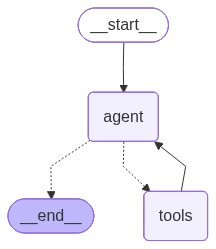

In [18]:
tools = [retriever_tool, wiki_tool]

## create the native Langgraph react agent
react_node=create_react_agent(llm,tools)
react_node

In [19]:
class AgentState(TypedDict):
    messages: Annotated[Sequence[BaseMessage], add_messages]

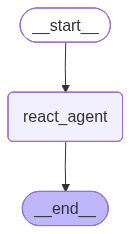

In [20]:
builder = StateGraph(AgentState)

builder.add_node("react_agent", react_node)
builder.set_entry_point("react_agent")
builder.add_edge("react_agent", END)

graph = builder.compile()
graph

In [21]:
if __name__ == "__main__":
    user_query = "What is an agent loop and how does Wikipedia describe autonomous agents?"
    state = {"messages": [HumanMessage(content=user_query)]}
    result = graph.invoke(state)

    print("\n✅ Final Answer:\n", result["messages"][-1].content)


✅ Final Answer:
 ### What an **agent loop** is

In the context of artificial‑intelligence and software‑agent design, an **agent loop** (sometimes called a *sense‑think‑act* loop) is the recurring cycle that an autonomous system follows in order to operate in its environment. The loop can be broken down into three basic stages:

| Stage | What happens | Typical implementation |
|-------|--------------|------------------------|
| **Sense (or Perceive)** | The agent gathers data from its surroundings—e.g., reading sensors, scraping a web page, receiving a user message, or querying an API. | Sensor drivers, web‑scrapers, event listeners, or language‑model prompts that fetch the current state. |
| **Think (or Decide)** | The agent processes the observed information, updates its internal model, and selects a next action. This may involve planning, reasoning, calling a language model, running a reinforcement‑learning policy, or consulting a knowledge base. | Decision‑making algorithms, promp

In [23]:
from langchain_community.document_loaders import WebBaseLoader, ArxivLoader, TextLoader

In [ ]:
### Generic function to create a retrieval tool
from pathlib import Path


def make_retriever_tool_from_text(file, name, desc):
    file_path = Path(file)
    if not file_path.exists():
        raise FileNotFoundError(f"File not found: {file_path}")

    docs = TextLoader(str(file_path), encoding="utf-8").load()
    chunks = RecursiveCharacterTextSplitter(chunk_size=500, chunk_overlap=50).split_documents(docs)
    vs = FAISS.from_documents(chunks, OpenAIEmbeddings())
    retriever = vs.as_retriever()

    def tool_func(query: str) -> str:
        print(f"📚 Using tool: {name}")
        results = retriever.invoke(query)
        return "\n\n".join(doc.page_content for doc in results)

    return Tool(name=name, description=desc, func=tool_func)


# Wikipedia Tool
def wikipedia_search(query: str) -> str:
    print("🌐 Searching Wikipedia...")
    wiki_tool = WikipediaQueryRun(api_wrapper=WikipediaAPIWrapper())
    return wiki_tool.run(query)

wiki_tool = Tool(
    name="Wikipedia",
    description="Use this tool to fetch general world knowledge from Wikipedia.",
    func=wikipedia_search
)

# ArXiv Tool
def arxiv_search(query: str) -> str:
    print("🧪 Searching ArXiv...")
    results = ArxivLoader(query).load()
    return "\n\n".join(doc.page_content[:1000] for doc in results[:2]) or "No papers found."

arxiv_tool = Tool(
    name="ArxivSearch",
    description="Use this tool to fetch recent academic papers on technical topics.",
    func=arxiv_search
)


In [37]:
internal_tool_1 = make_retriever_tool_from_text(
    "sample_docs.txt",
    "InternalTechDocs",
    "Search internal tech documents for proprietary architecture and methods."
)
internal_tool_1

RuntimeError: Error loading sample_docs.txt

In [38]:
internal_tool_2 = make_retriever_tool_from_text(
    "research_notes.txt",
    "InternalResearchNotes",
    "Search internal research notes for experimental results and agent designs."
)
internal_tool_2

RuntimeError: Error loading research_notes.txt

In [ ]:
tools=[wiki_tool,arxiv_tool,internal_tool_1,internal_tool_2]

react_node=create_react_agent(llm,tools)
react_node

In [ ]:
## same as above just add added more tools for RAG